In [1]:
import sys
import os
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()
# Go up one level to project root (adjust based on your structure)
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

In [2]:
from pathlib import Path
from src.analyze.GMM_PCA_filter import XPSFilter
from src.analyze.PCA_normalizing import XPSAggregator

In [3]:
Result_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\1011long")
process_dir = Result_folder / 'analysis_logic_test' / 'results'
output_dir = Result_folder / 'analysis_logic_test' / 'filtered'

Safety Check [pass1]: Removed 32 rows containing NaN values.


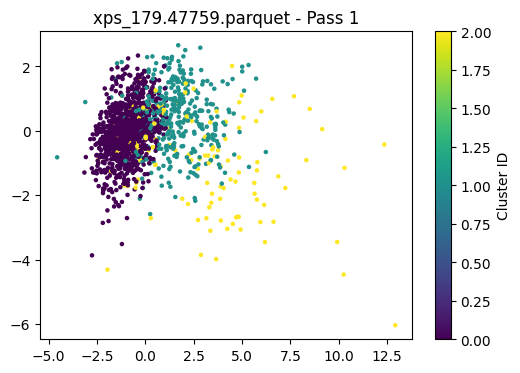

cluster_pass1
0    67.32991
1    23.94095
2     8.72914
Name: proportion, dtype: float64


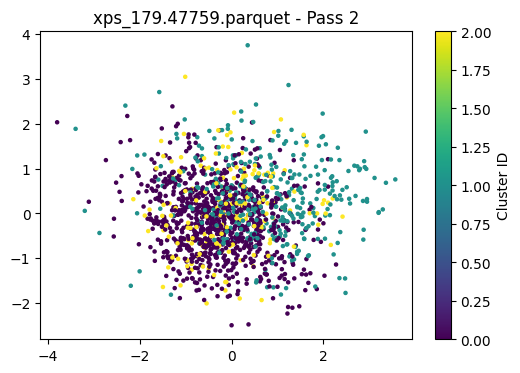

cluster_pass2
0    62.095640
1    25.738397
2    12.165963
Name: proportion, dtype: float64

Final retention: 1422/1590 (89.4%)


In [8]:
filter = XPSFilter(n_pca=3)
filteredfile = filter.process_with_manual_filter(process_dir / 'xps_179.47759.parquet')

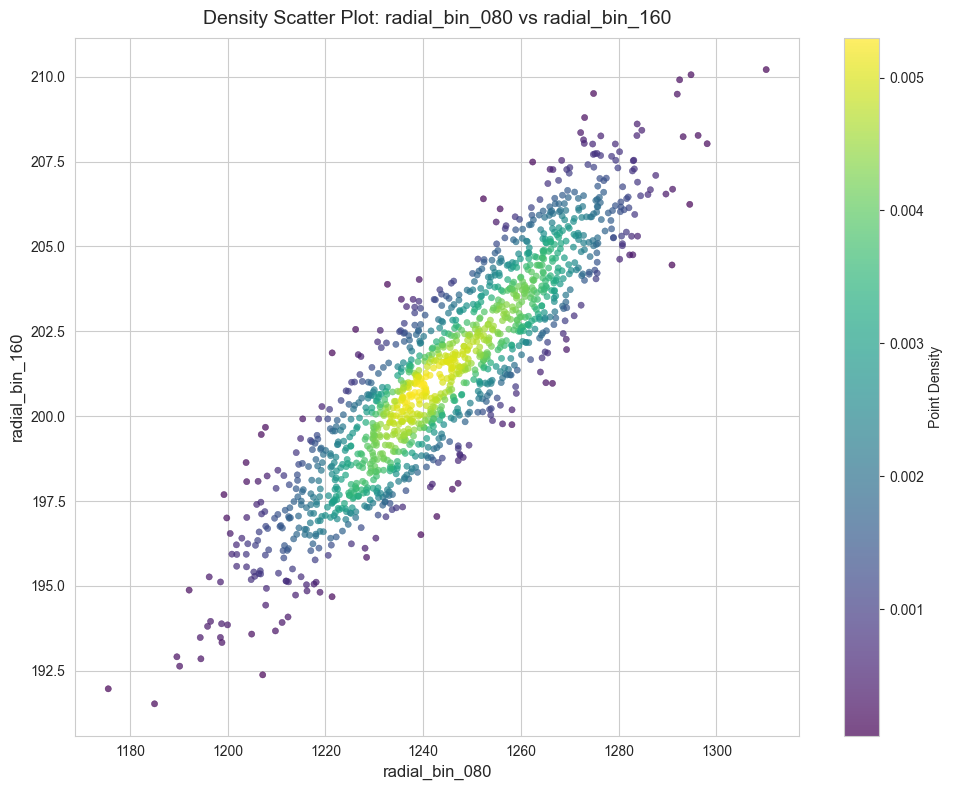

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")

# 1. 准备数据
x = filteredfile["radial_bin_040"]
y = filteredfile["radial_bin_120"]
#y = df["center_y"]

# 2. 计算点的局部密度（核心：用高斯核估计密度）
from scipy.stats import gaussian_kde
# 过滤缺失值
mask = ~np.isnan(x) & ~np.isnan(y)
x_valid = x[mask]
y_valid = y[mask]
# 计算密度值
kde = gaussian_kde(np.vstack([x_valid, y_valid]))
density = kde(np.vstack([x_valid, y_valid]))

# 3. 绘制密度散点图
fig, ax = plt.subplots(figsize=(10, 8))
scatter = sns.scatterplot(
    x=x_valid,
    y=y_valid,
    c=density,  # 用密度值映射颜色
    cmap="viridis",  # 配色方案（推荐：viridis/plasma/inferno）
    s=20,  # 点的大小
    alpha=0.7,  # 透明度，避免重叠遮挡
    edgecolor=None,  # 关闭点的边框
    ax=ax
)

# 4. 添加颜色条（展示密度与颜色的对应关系）
cbar = plt.colorbar(scatter.collections[0], ax=ax)
cbar.set_label("Point Density", fontsize=10)

# 5. 添加标题和标签
ax.set_title("Density Scatter Plot: radial_bin_080 vs radial_bin_160", fontsize=14, pad=10)
ax.set_xlabel("radial_bin_080", fontsize=12)
ax.set_ylabel("radial_bin_160", fontsize=12)

# 6. 优化布局
plt.tight_layout()
plt.show()

In [7]:
filter = XPSFilter(n_pca=5)
filter.auto_batch_filter(process_dir,output_dir,3,2,10)

Safety Check [pass1]: Removed 18 rows containing NaN values.
File xps_179.46260.parquet: Retained 1404 samples (88.9%)
Safety Check [pass1]: Removed 32 rows containing NaN values.
File xps_179.47759.parquet: Retained 1405 samples (88.4%)
Safety Check [pass1]: Removed 9 rows containing NaN values.
File xps_179.49258.parquet: Retained 1495 samples (94.0%)
Safety Check [pass1]: Removed 1 rows containing NaN values.
File xps_179.50757.parquet: Retained 1550 samples (97.5%)
Safety Check [pass1]: Removed 18 rows containing NaN values.
File xps_179.52256.parquet: Retained 1483 samples (93.3%)
Safety Check [pass1]: Removed 25 rows containing NaN values.
File xps_179.53755.parquet: Retained 1500 samples (93.8%)
Safety Check [pass1]: Removed 27 rows containing NaN values.
File xps_179.54504.parquet: Retained 1496 samples (95.3%)
Safety Check [pass1]: Removed 16 rows containing NaN values.
File xps_179.55254.parquet: Retained 1477 samples (93.5%)
Safety Check [pass1]: Removed 20 rows containing N

In [9]:
norm_dir = Result_folder / 'analysis_logic_test' / 'stats'
normalizer = XPSAggregator(norm_dir, 720)
normalizer.aggregate_directory(output_dir,60,200)

Aggregated auto_filtered_xps_179.46260.parquet: 1404 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.47759.parquet: 1405 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.49258.parquet: 1495 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.50757.parquet: 1550 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.52256.parquet: 1483 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.53755.parquet: 1500 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.54504.parquet: 1496 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.55254.parquet: 1477 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.56003.parquet: 1514 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.56753.parquet: 1493 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.57503.parquet: 1548 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.58102.parquet: 1615 frames (Full 720 bins).
Aggregated auto_filtered_xps_179.58552.parquet: 1481 frames (Full 720 bins).